# ClarityNet: Baseline CNN Training

This notebook:
1. Loads the train/val/test splits from notebook 02
2. Defines the U-Net CNN baseline architecture
3. Implements the training loop with validation on seen and unseen noise
4. Tracks the generalization gap during training
5. Saves checkpoints and training history

**Prerequisites:** Run notebook 02 first to ensure data is ready.

In [1]:
# Imports
import os
import sys
import json
import random
import numpy as np
import matplotlib.pyplot as plt
# %matplotlib inline

from pathlib import Path
from datetime import datetime

import torch
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm

import soundfile as sf
import IPython.display as ipd


PROJECT_ROOT = Path("../").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.dataset import WaveformDataset
from src.data.audio_utils import compute_stft, SAMPLE_RATE
from src.evaluation.metrics import evaluate_with_metrics

# Set seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

print("Imports successful!")

Imports successful!


In [2]:
print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU      : {torch.cuda.get_device_name(0)}")

PyTorch  : 2.10.0+cu128
CUDA     : True
GPU      : NVIDIA GeForce RTX 2080 SUPER


## Configuration

In [3]:
# # Audio parameters (must match notebook 02)
# SAMPLE_RATE = 16000
# SEGMENT_DURATION = 4.0
# SEGMENT_SAMPLES = int(SAMPLE_RATE * SEGMENT_DURATION)
# N_FFT = 512
# HOP_LENGTH = 128
# SNR_MIN_DB = 0
# SNR_MAX_DB = 20

# Training hyperparameters
BATCH_SIZE = 8
LEARNING_RATE = 1e-3
NUM_EPOCHS = 50
PATIENCE = 10  # Early stopping patience
SAVE_EVERY = 5  # Save checkpoint every N epochs

# Paths
PROJECT_ROOT = Path("..").resolve() 
# DATA_DIR = PROJECT_ROOT / "data/raw"
# CLEAN_DIR = DATA_DIR / "clean_speech"
# NOISE_DIR = DATA_DIR / "noise"
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints/baseline_cnn"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR = PROJECT_ROOT / "results/baseline_cnn"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Device
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

print(f"Configuration:")
print(f"  Device: {DEVICE}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Checkpoint dir: {CHECKPOINT_DIR}")
print(f"  Results dir: {RESULTS_DIR}")

Configuration:
  Device: cuda
  Batch size: 8
  Learning rate: 0.001
  Epochs: 50
  Checkpoint dir: /home/paul/Desktop/projects/clarity-net/checkpoints/baseline_cnn
  Results dir: /home/paul/Desktop/projects/clarity-net/results/baseline_cnn


## Dataset Class (from Notebook 02)

In [4]:
class CNNDataset(WaveformDataset):
    def __getitem__(self, idx):
        sample = super().__getitem__(idx)

        clean = sample["clean_audio"].numpy()
        noisy = sample["noisy_audio"].numpy()

        clean_mag, _ = compute_stft(clean)
        noisy_mag, noisy_phase = compute_stft(noisy)

        return {
            "pair_id": sample["pair_id"],
            "noisy": torch.tensor(noisy_mag, dtype=torch.float32).unsqueeze(0),
            "clean": torch.tensor(clean_mag, dtype=torch.float32).unsqueeze(0),
            "phase": torch.tensor(noisy_phase, dtype=torch.float32),
            "snr": sample["snr"],
        }

print("✓ Dataset class defined")

✓ Dataset class defined


## Create Datasets

In [5]:
print("Creating datasets...\n")

MANIFEST_PATH = PROJECT_ROOT / "data/processed/speech_manifest.json"

train_dataset = CNNDataset(MANIFEST_PATH, "train", root_dir=PROJECT_ROOT)
val_seen_dataset = CNNDataset(MANIFEST_PATH, "val_seen", root_dir=PROJECT_ROOT)
val_unseen_dataset = CNNDataset(MANIFEST_PATH, "val_unseen", root_dir=PROJECT_ROOT)
test_seen_dataset = CNNDataset(MANIFEST_PATH, "test_seen", root_dir=PROJECT_ROOT)
test_unseen_dataset = CNNDataset(MANIFEST_PATH, "test_unseen", root_dir=PROJECT_ROOT)

print("\n" + "="*60)
print(f"Training:          {len(train_dataset)} pairs")
print(f"Validation (seen): {len(val_seen_dataset)} pairs")
print(f"Validation (uns.): {len(val_unseen_dataset)} pairs")
print(f"Test (seen):       {len(test_seen_dataset)} pairs")
print(f"Test (uns.):       {len(test_unseen_dataset)} pairs")
print("="*60)

Creating datasets...


Training:          1245 pairs
Validation (seen): 56 pairs
Validation (uns.): 56 pairs
Test (seen):       49 pairs
Test (uns.):       49 pairs


## Create DataLoaders

In [6]:
# Ensure shuffling is deterministic for reproducibility
train_gen = torch.Generator().manual_seed(42)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, generator=train_gen)
val_seen_loader = DataLoader(val_seen_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
val_unseen_loader = DataLoader(val_unseen_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_seen_loader = DataLoader(test_seen_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_unseen_loader = DataLoader(test_unseen_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"DataLoaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val (seen) batches: {len(val_seen_loader)}")
print(f"  Val (unseen) batches: {len(val_unseen_loader)}")
print(f"  Test (seen) batches: {len(test_seen_loader)}")
print(f"  Test (unseen) batches: {len(test_unseen_loader)}")

DataLoaders created:
  Train batches: 156
  Val (seen) batches: 7
  Val (unseen) batches: 7
  Test (seen) batches: 7
  Test (unseen) batches: 7


## Define U-Net CNN Model

In [7]:
"""
Size-preserving U-Net CNN for speech enhancement.
Guarantees output size exactly matches input size.
 
Replace the UNetCNN class in notebook 03 with this version.
"""
 
import torch
import torch.nn as nn
import torch.nn.functional as F
 
 
class UNetCNN(nn.Module):
    """
    U-Net baseline with guaranteed size preservation.
    Uses interpolate for upsampling to ensure exact size matching.
    """
    
    def __init__(self, in_channels=1, base_channels=32):
        super(UNetCNN, self).__init__()
        
        # Encoder
        self.enc1 = self._conv_block(in_channels, base_channels)
        self.enc2 = self._conv_block(base_channels, base_channels * 2)
        self.enc3 = self._conv_block(base_channels * 2, base_channels * 4)
        self.enc4 = self._conv_block(base_channels * 4, base_channels * 8)
        
        # Bottleneck
        self.bottleneck = self._conv_block(base_channels * 8, base_channels * 16)
        
        # Decoder
        self.dec4 = self._conv_block(base_channels * 16 + base_channels * 8, base_channels * 8)
        self.dec3 = self._conv_block(base_channels * 8 + base_channels * 4, base_channels * 4)
        self.dec2 = self._conv_block(base_channels * 4 + base_channels * 2, base_channels * 2)
        self.dec1 = self._conv_block(base_channels * 2 + base_channels, base_channels)
        
        # Output
        self.out_conv = nn.Conv2d(base_channels, in_channels, kernel_size=1)
        self.sigmoid = nn.Sigmoid()
    
    def _conv_block(self, in_c, out_c):
        """Convolutional block with padding to preserve size."""
        return nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        # Store input size for upsampling
        input_size = x.shape[2:]  # (H, W)
        
        # Encoder with size tracking
        enc1 = self.enc1(x)  # Same size as input
        enc1_pooled = F.max_pool2d(enc1, kernel_size=2, stride=2)
        enc1_size = enc1.shape[2:]
        
        enc2 = self.enc2(enc1_pooled)
        enc2_pooled = F.max_pool2d(enc2, kernel_size=2, stride=2)
        enc2_size = enc2.shape[2:]
        
        enc3 = self.enc3(enc2_pooled)
        enc3_pooled = F.max_pool2d(enc3, kernel_size=2, stride=2)
        enc3_size = enc3.shape[2:]
        
        enc4 = self.enc4(enc3_pooled)
        enc4_pooled = F.max_pool2d(enc4, kernel_size=2, stride=2)
        enc4_size = enc4.shape[2:]
        
        # Bottleneck
        bottleneck = self.bottleneck(enc4_pooled)
        
        # Decoder with exact size matching via interpolate
        dec4 = F.interpolate(bottleneck, size=enc4_size, mode='bilinear', align_corners=False)
        dec4 = torch.cat([dec4, enc4], dim=1)
        dec4 = self.dec4(dec4)
        
        dec3 = F.interpolate(dec4, size=enc3_size, mode='bilinear', align_corners=False)
        dec3 = torch.cat([dec3, enc3], dim=1)
        dec3 = self.dec3(dec3)
        
        dec2 = F.interpolate(dec3, size=enc2_size, mode='bilinear', align_corners=False)
        dec2 = torch.cat([dec2, enc2], dim=1)
        dec2 = self.dec2(dec2)
        
        dec1 = F.interpolate(dec2, size=enc1_size, mode='bilinear', align_corners=False)
        dec1 = torch.cat([dec1, enc1], dim=1)
        dec1 = self.dec1(dec1)
        
        # Final upsampling to exactly match input size
        dec1 = F.interpolate(dec1, size=input_size, mode='bilinear', align_corners=False)
        
        # Output mask
        mask = self.sigmoid(self.out_conv(dec1))
        
        # Apply mask to input
        enhanced = x * mask
        
        return enhanced


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# Create model
model = UNetCNN(in_channels=1, base_channels=32).to(DEVICE)
print(f"Model created with {count_parameters(model):,} parameters")
    
# Test multiple sizes to ensure it works
test_sizes = [
    (2, 1, 257, 501),  # Actual STFT size from data
    (2, 1, 257, 251),  # Alternative size
    (2, 1, 256, 500),  # Even dimensions
]
    
print("Model Architecture Test")
print(f"Total parameters: {count_parameters(model):,}\n")
    
for test_size in test_sizes:
    x = torch.randn(*test_size).to(DEVICE)
        
    with torch.no_grad():
         output = model(x).cpu()
        
    print(f"Input:  {tuple(x.shape)} -> Output: {tuple(output.shape)}")
    assert x.shape == output.shape, f"Size mismatch! {x.shape} != {output.shape}"
    
    print("\n✓ All tests passed! Output size matches input size exactly.")

# Test forward pass
test_batch = next(iter(train_loader))
with torch.no_grad():
    test_out = model(test_batch['noisy'].to(DEVICE))
print(f"Test forward pass: {test_batch['noisy'].shape} -> {test_out.shape}")
print("✓ Model ready")

Model created with 7,851,969 parameters
Model Architecture Test
Total parameters: 7,851,969

Input:  (2, 1, 257, 501) -> Output: (2, 1, 257, 501)

✓ All tests passed! Output size matches input size exactly.
Input:  (2, 1, 257, 251) -> Output: (2, 1, 257, 251)

✓ All tests passed! Output size matches input size exactly.
Input:  (2, 1, 256, 500) -> Output: (2, 1, 256, 500)

✓ All tests passed! Output size matches input size exactly.
Test forward pass: torch.Size([8, 1, 257, 501]) -> torch.Size([8, 1, 257, 501])
✓ Model ready


## Training Setup

In [8]:
# Loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Learning rate scheduler (optional)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

print(f"Loss function: MSE")
print(f"Optimizer: Adam (lr={LEARNING_RATE})")
print(f"Scheduler: ReduceLROnPlateau")

Loss function: MSE
Optimizer: Adam (lr=0.001)
Scheduler: ReduceLROnPlateau


## Training Loop

In [9]:
# Training history
history = {
    'train_loss': [],
    'val_seen_loss': [],
    'val_unseen_loss': [],
    'generalization_gap': [],
    'learning_rate': []
}

best_val_loss = float('inf')
epochs_without_improvement = 0


def train_epoch():
    """Train for one epoch."""
    model.train()
    total_loss = 0
    
    pbar = tqdm(train_loader, desc="Training")
    for batch in pbar:
        noisy = batch['noisy'].to(DEVICE)
        clean = batch['clean'].to(DEVICE)
        
        # Forward
        enhanced = model(noisy)
        loss = criterion(enhanced, clean)
        
        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.6f}'})
    
    return total_loss / len(train_loader)


def validate(val_loader, desc="Validation"):
    """Validate on a dataset."""
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=desc, leave=False):
            noisy = batch['noisy'].to(DEVICE)
            clean = batch['clean'].to(DEVICE)
            
            enhanced = model(noisy)
            loss = criterion(enhanced, clean)
            total_loss += loss.item()
    
    return total_loss / len(val_loader)


def save_checkpoint(epoch, is_best=False):
    """Save model checkpoint."""
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'best_val_loss': best_val_loss,
        'history': history
    }
    
    if is_best:
        path = CHECKPOINT_DIR / 'best_model.pth'
        torch.save(checkpoint, path)
        print(f"  ✓ Saved best model to {path}")
    else:
        path = CHECKPOINT_DIR / f'checkpoint_epoch_{epoch}.pth'
        torch.save(checkpoint, path)


print("Training functions defined. Ready to train!")

Training functions defined. Ready to train!


## Run Training

In [10]:
print("="*60)
print("Starting Training")
print("="*60)

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\nEpoch {epoch}/{NUM_EPOCHS}")
    print("-" * 60)
    
    # Train
    train_loss = train_epoch()
    
    # Validate
    val_seen_loss = validate(val_seen_loader, "Val (seen)")
    val_unseen_loss = validate(val_unseen_loader, "Val (unseen)")
    
    # Compute gap
    gap = val_unseen_loss - val_seen_loss
    
    # Update scheduler
    scheduler.step(val_seen_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    # Log
    history['train_loss'].append(train_loss)
    history['val_seen_loss'].append(val_seen_loss)
    history['val_unseen_loss'].append(val_unseen_loss)
    history['generalization_gap'].append(gap)
    history['learning_rate'].append(current_lr)
    
    print(f"\nResults:")
    print(f"  Train Loss:         {train_loss:.6f}")
    print(f"  Val (seen) Loss:    {val_seen_loss:.6f}")
    print(f"  Val (unseen) Loss:  {val_unseen_loss:.6f}")
    print(f"  Generalization Gap: {gap:.6f}")
    print(f"  Learning Rate:      {current_lr:.2e}")
    
    # Checkpointing
    if val_seen_loss < best_val_loss:
        best_val_loss = val_seen_loss
        epochs_without_improvement = 0
        save_checkpoint(epoch, is_best=True)
    else:
        epochs_without_improvement += 1
        print(f"  No improvement for {epochs_without_improvement} epoch(s)")
    
    if epoch % SAVE_EVERY == 0:
        save_checkpoint(epoch, is_best=False)
    
    # Early stopping
    if epochs_without_improvement >= PATIENCE:
        print(f"\n⚠️  Early stopping triggered after {epoch} epochs")
        break

print("\n" + "="*60)
print("Training Complete!")
print(f"Best validation loss: {best_val_loss:.6f}")
print("="*60)

# Save final history
with open(RESULTS_DIR / 'training_history.json', 'w') as f:
    json.dump(history, f, indent=2)
print(f"Training history saved to {RESULTS_DIR / 'training_history.json'}")

Starting Training

Epoch 1/50
------------------------------------------------------------


Training:   0%|          | 0/156 [00:00<?, ?it/s]

Val (seen):   0%|          | 0/7 [00:00<?, ?it/s]

Val (unseen):   0%|          | 0/7 [00:00<?, ?it/s]


Results:
  Train Loss:         0.022405
  Val (seen) Loss:    0.014635
  Val (unseen) Loss:  0.016816
  Generalization Gap: 0.002181
  Learning Rate:      1.00e-03
  ✓ Saved best model to /home/paul/Desktop/projects/clarity-net/checkpoints/baseline_cnn/best_model.pth

Epoch 2/50
------------------------------------------------------------


...


Results:
  Train Loss:         0.001852
  Val (seen) Loss:    0.002422
  Val (unseen) Loss:  0.008680
  Generalization Gap: 0.006258
  Learning Rate:      5.00e-04
  ✓ Saved best model to /home/paul/Desktop/projects/clarity-net/checkpoints/baseline_cnn/best_model.pth

Epoch 50/50
------------------------------------------------------------


Training:   0%|          | 0/156 [00:00<?, ?it/s]

Val (seen):   0%|          | 0/7 [00:00<?, ?it/s]

Val (unseen):   0%|          | 0/7 [00:00<?, ?it/s]


Results:
  Train Loss:         0.001836
  Val (seen) Loss:    0.002524
  Val (unseen) Loss:  0.008906
  Generalization Gap: 0.006382
  Learning Rate:      5.00e-04
  No improvement for 1 epoch(s)

Training Complete!
Best validation loss: 0.002422
Training history saved to /home/paul/Desktop/projects/clarity-net/results/baseline_cnn/training_history.json


## Visualize Training

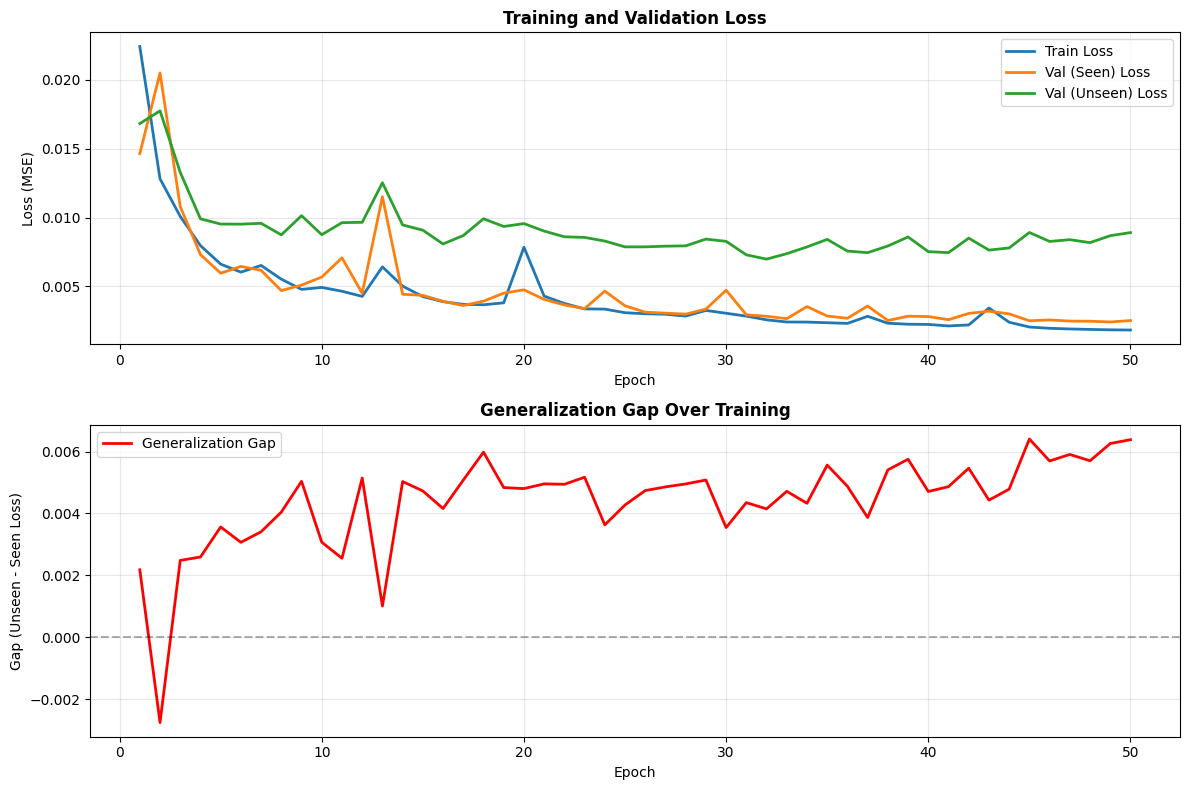

Training curves saved to /home/paul/Desktop/projects/clarity-net/results/baseline_cnn/training_curves.png


In [11]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

epochs_range = range(1, len(history['train_loss']) + 1)

# Loss curves
axes[0].plot(epochs_range, history['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(epochs_range, history['val_seen_loss'], label='Val (Seen) Loss', linewidth=2)
axes[0].plot(epochs_range, history['val_unseen_loss'], label='Val (Unseen) Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_title('Training and Validation Loss', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Generalization gap
axes[1].plot(epochs_range, history['generalization_gap'], 
             color='red', linewidth=2, label='Generalization Gap')
axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.3)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Gap (Unseen - Seen Loss)')
axes[1].set_title('Generalization Gap Over Training', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_curves.png', dpi=150)
plt.show()

print(f"Training curves saved to {RESULTS_DIR / 'training_curves.png'}")

## Run Evaluation

In [13]:
print("="*60)
print("Evaluating Model")
print("="*60)

# Evaluate on seen noise test set
print("\nEvaluating on SEEN noise types...")
results_seen = evaluate_with_metrics(model, test_seen_loader, "Test (Seen)", device=DEVICE)

# Evaluate on unseen noise test set
print("\nEvaluating on UNSEEN noise types...")
results_unseen = evaluate_with_metrics(model, test_unseen_loader, "Test (Unseen)", device=DEVICE)

print("\n" + "="*60)
print("Results Summary")
print("="*60)

print("\nSEEN Noise Types:")
print(f"  MSE:  {results_seen['mse']:.6f}")
print(f"  PESQ: {results_seen['pesq_mean']:.3f} ± {results_seen['pesq_std']:.3f}")
print(f"  STOI: {results_seen['stoi_mean']:.3f} ± {results_seen['stoi_std']:.3f}")

print("\nUNSEEN Noise Types:")
print(f"  MSE:  {results_unseen['mse']:.6f}")
print(f"  PESQ: {results_unseen['pesq_mean']:.3f} ± {results_unseen['pesq_std']:.3f}")
print(f"  STOI: {results_unseen['stoi_mean']:.3f} ± {results_unseen['stoi_std']:.3f}")

print("\nGeneralization Gap:")
print(f"  PESQ: {results_seen['pesq_mean'] - results_unseen['pesq_mean']:.3f}")
print(f"  STOI: {results_seen['stoi_mean'] - results_unseen['stoi_mean']:.3f}")

# Save results
results_summary = {
    'seen': {
        'mse': results_seen['mse'],
        'pesq_mean': results_seen['pesq_mean'],
        'pesq_std': results_seen['pesq_std'],
        'stoi_mean': results_seen['stoi_mean'],
        'stoi_std': results_seen['stoi_std']
    },
    'unseen': {
        'mse': results_unseen['mse'],
        'pesq_mean': results_unseen['pesq_mean'],
        'pesq_std': results_unseen['pesq_std'],
        'stoi_mean': results_unseen['stoi_mean'],
        'stoi_std': results_unseen['stoi_std']
    }
}

with open(RESULTS_DIR / 'evaluation_results.json', 'w') as f:
    json.dump(results_summary, f, indent=2)

print(f"\n✓ Results saved to {RESULTS_DIR / 'evaluation_results.json'}")

Evaluating Model

Evaluating on SEEN noise types...


Test (Seen):  57%|█████▋    | 4/7 [00:02<00:02,  1.40it/s]/home/paul/Desktop/projects/clarity-net/.venv/lib/python3.12/site-packages/pystoi/stoi.py:66: RuntimeWarning: Not enough STFT frames to compute intermediate intelligibility measure after removing silent frames. Returning 1e-5. Please check you wav files
  warnings.warn('Not enough STFT frames to compute intermediate '
Test (Seen): 100%|██████████| 7/7 [00:04<00:00,  1.58it/s]



Evaluating on UNSEEN noise types...


Test (Unseen): 100%|██████████| 7/7 [00:04<00:00,  1.55it/s]


Results Summary

SEEN Noise Types:
  MSE:  0.003160
  PESQ: 3.315 ± 0.679
  STOI: 0.938 ± 0.144

UNSEEN Noise Types:
  MSE:  0.012319
  PESQ: 3.019 ± 0.741
  STOI: 0.931 ± 0.143

Generalization Gap:
  PESQ: 0.296
  STOI: 0.008

✓ Results saved to /home/paul/Desktop/projects/clarity-net/results/baseline_cnn/evaluation_results.json


## Visualize Audio Samples

Sample 1 - SNR: 14.0 dB
  PESQ: 3.309
  STOI: 0.996



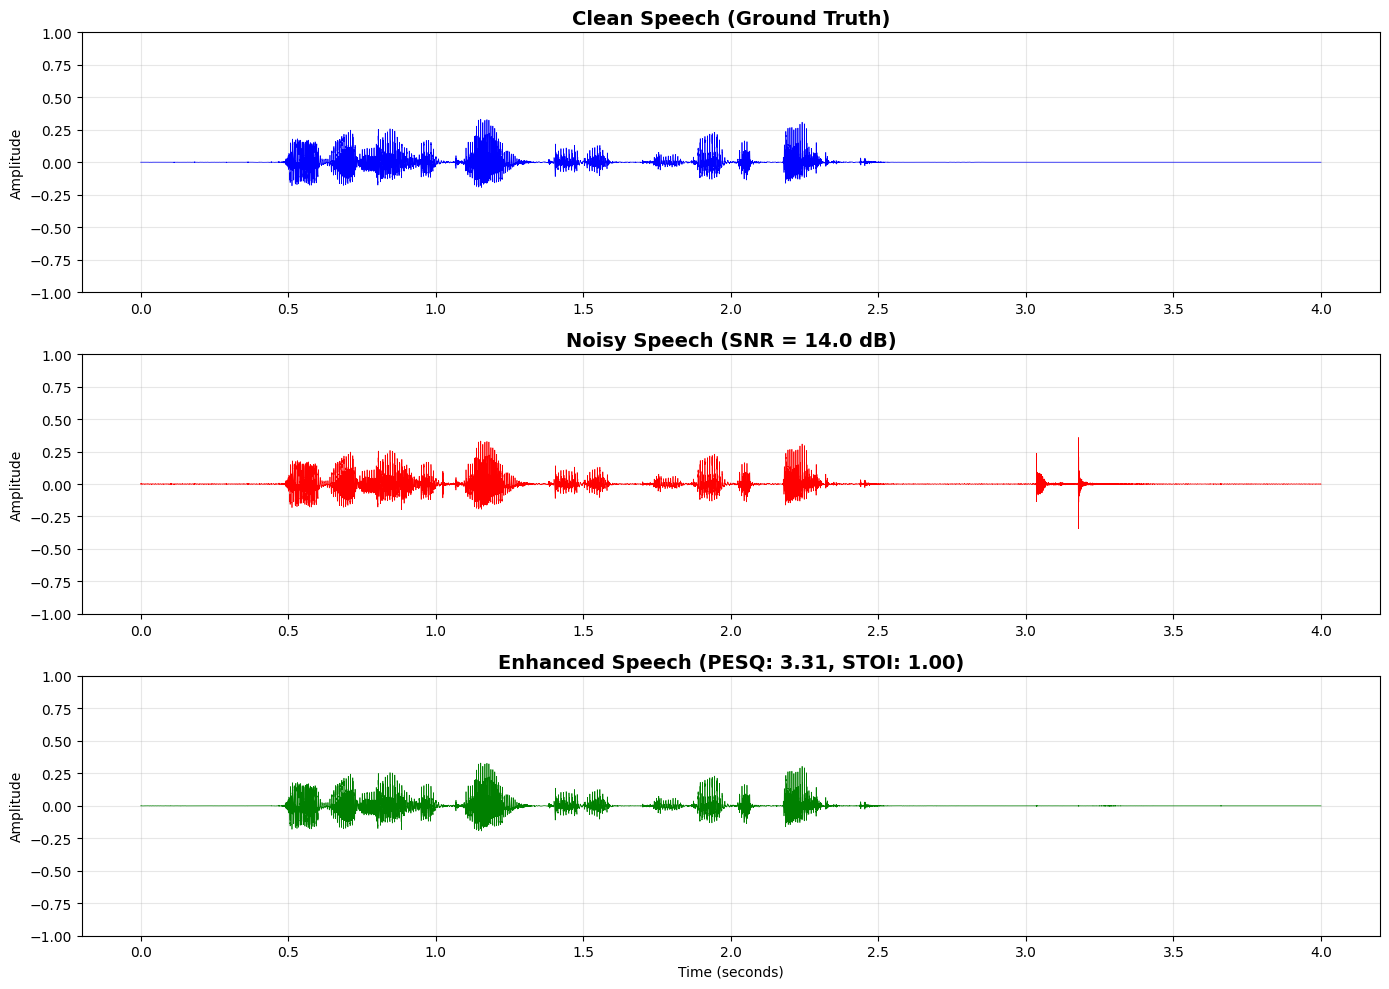

Waveform saved to /home/paul/Desktop/projects/clarity-net/results/baseline_cnn/waveform_comparison_sample_0.png


In [14]:
# Pick a good sample (high PESQ improvement)
sample_idx = 0
sample = results_seen['audio_samples'][sample_idx]

print(f"Sample {sample_idx + 1} - SNR: {sample['snr']:.1f} dB")
print(f"  PESQ: {sample['pesq']:.3f}")
print(f"  STOI: {sample['stoi']:.3f}")
print("\n" + "="*60)

# Create time axis for waveforms
time_axis = np.arange(len(sample['clean'])) / SAMPLE_RATE

# Plot waveforms
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(time_axis, sample['clean'], linewidth=0.5, color='blue')
axes[0].set_title('Clean Speech (Ground Truth)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Amplitude')
axes[0].set_ylim(-1, 1)
axes[0].grid(True, alpha=0.3)

axes[1].plot(time_axis, sample['noisy'], linewidth=0.5, color='red')
axes[1].set_title(f'Noisy Speech (SNR = {sample["snr"]:.1f} dB)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Amplitude')
axes[1].set_ylim(-1, 1)
axes[1].grid(True, alpha=0.3)

axes[2].plot(time_axis, sample['enhanced'], linewidth=0.5, color='green')
axes[2].set_title(f'Enhanced Speech (PESQ: {sample["pesq"]:.2f}, STOI: {sample["stoi"]:.2f})', 
                  fontsize=14, fontweight='bold')
axes[2].set_xlabel('Time (seconds)')
axes[2].set_ylabel('Amplitude')
axes[2].set_ylim(-1, 1)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / f'waveform_comparison_sample_{sample_idx}.png', dpi=150)
plt.show()

print(f"Waveform saved to {RESULTS_DIR / f'waveform_comparison_sample_{sample_idx}.png'}")

## Overlay Plots

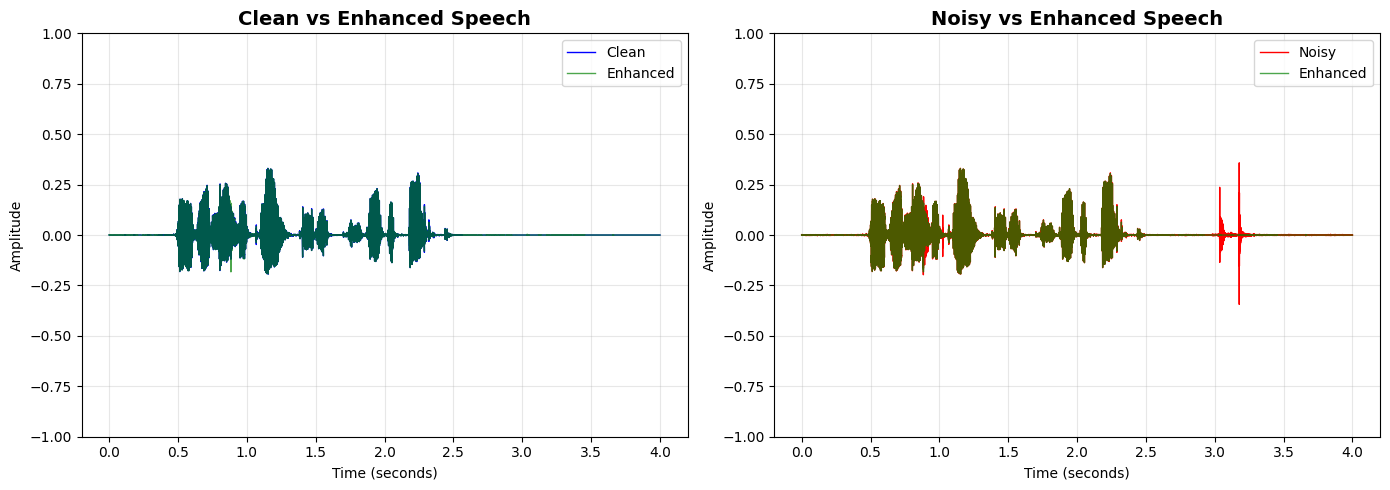

Overlay plots saved to /home/paul/Desktop/projects/clarity-net/results/baseline_cnn/overlay_comparison.png


In [15]:
# Create overlay plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Clean vs Enhanced
axes[0].plot(time_axis, sample['clean'], linewidth=1, color='blue', label='Clean')
axes[0].plot(time_axis, sample['enhanced'], linewidth=1, color='green', alpha=0.7, label='Enhanced')
axes[0].set_title('Clean vs Enhanced Speech', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('Amplitude')
axes[0].set_ylim(-1, 1)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Noisy vs Enhanced
axes[1].plot(time_axis, sample['noisy'], linewidth=1, color='red', label='Noisy')
axes[1].plot(time_axis, sample['enhanced'], linewidth=1, color='green', alpha=0.7, label='Enhanced')
axes[1].set_title('Noisy vs Enhanced Speech', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Amplitude')
axes[1].set_ylim(-1, 1)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'overlay_comparison.png', dpi=150)
plt.show()

print(f"Overlay plots saved to {RESULTS_DIR / 'overlay_comparison.png'}")

## Audio Playback

In [16]:
# Debug audio data before playback
print("Audio Data Inspection:")
print(f"Sample rate: {SAMPLE_RATE} Hz")
print(f"Clean audio shape: {sample['clean'].shape}")
print(f"Clean audio dtype: {sample['clean'].dtype}")
print(f"Clean audio range: [{sample['clean'].min():.6f}, {sample['clean'].max():.6f}]")
print(f"Clean audio RMS: {np.sqrt(np.mean(sample['clean']**2)):.6f}")
print(f"Clean audio duration: {len(sample['clean']) / SAMPLE_RATE:.2f} seconds")

print(f"\nNoisy audio shape: {sample['noisy'].shape}")
print(f"Noisy audio range: [{sample['noisy'].min():.6f}, {sample['noisy'].max():.6f}]")
print(f"Noisy audio RMS: {np.sqrt(np.mean(sample['noisy']**2)):.6f}")

print(f"\nEnhanced audio shape: {sample['enhanced'].shape}")
print(f"Enhanced audio range: [{sample['enhanced'].min():.6f}, {sample['enhanced'].max():.6f}]")
print(f"Enhanced audio RMS: {np.sqrt(np.mean(sample['enhanced']**2)):.6f}")

# Check if audio is essentially silent
threshold = 1e-6
if np.max(np.abs(sample['clean'])) < threshold:
    print("\n⚠️  WARNING: Clean audio appears to be silent!")
if np.max(np.abs(sample['noisy'])) < threshold:
    print("\n⚠️  WARNING: Noisy audio appears to be silent!")
if np.max(np.abs(sample['enhanced'])) < threshold:
    print("\n⚠️  WARNING: Enhanced audio appears to be silent!")

print("\n" + "="*60)

Audio Data Inspection:
Sample rate: 16000 Hz
Clean audio shape: (64000,)
Clean audio dtype: float32
Clean audio range: [-0.194128, 0.330833]
Clean audio RMS: 0.033784
Clean audio duration: 4.00 seconds

Noisy audio shape: (64000,)
Noisy audio range: [-0.344001, 0.357948]
Noisy audio RMS: 0.034454

Enhanced audio shape: (64000,)
Enhanced audio range: [-0.193285, 0.329632]
Enhanced audio RMS: 0.033628



In [17]:
print("Clean Speech:")
display(ipd.Audio(sample['clean'], rate=SAMPLE_RATE))

print(f"\nNoisy Speech (SNR = {sample['snr']:.1f} dB):")
display(ipd.Audio(sample['noisy'], rate=SAMPLE_RATE))

print(f"\nEnhanced Speech (PESQ = {sample['pesq']:.2f}, STOI = {sample['stoi']:.2f}):")
display(ipd.Audio(sample['enhanced'], rate=SAMPLE_RATE))

Clean Speech:



Noisy Speech (SNR = 14.0 dB):



Enhanced Speech (PESQ = 3.31, STOI = 1.00):


In [18]:
# Try amplifying the audio for better playback (temporary test)
amplify_factor = 10.0  # Increase volume by 10x for testing

print("Amplified Clean Speech (10x louder):")
display(ipd.Audio(np.clip(sample['clean'] * amplify_factor, -1, 1), rate=SAMPLE_RATE))

print(f"\nAmplified Noisy Speech (10x louder, SNR = {sample['snr']:.1f} dB):")
display(ipd.Audio(np.clip(sample['noisy'] * amplify_factor, -1, 1), rate=SAMPLE_RATE))

print(f"\nAmplified Enhanced Speech (10x louder, PESQ = {sample['pesq']:.2f}, STOI = {sample['stoi']:.2f}):")
display(ipd.Audio(np.clip(sample['enhanced'] * amplify_factor, -1, 1), rate=SAMPLE_RATE))

Amplified Clean Speech (10x louder):



Amplified Noisy Speech (10x louder, SNR = 14.0 dB):



Amplified Enhanced Speech (10x louder, PESQ = 3.31, STOI = 1.00):


## Plot Metric Distributions

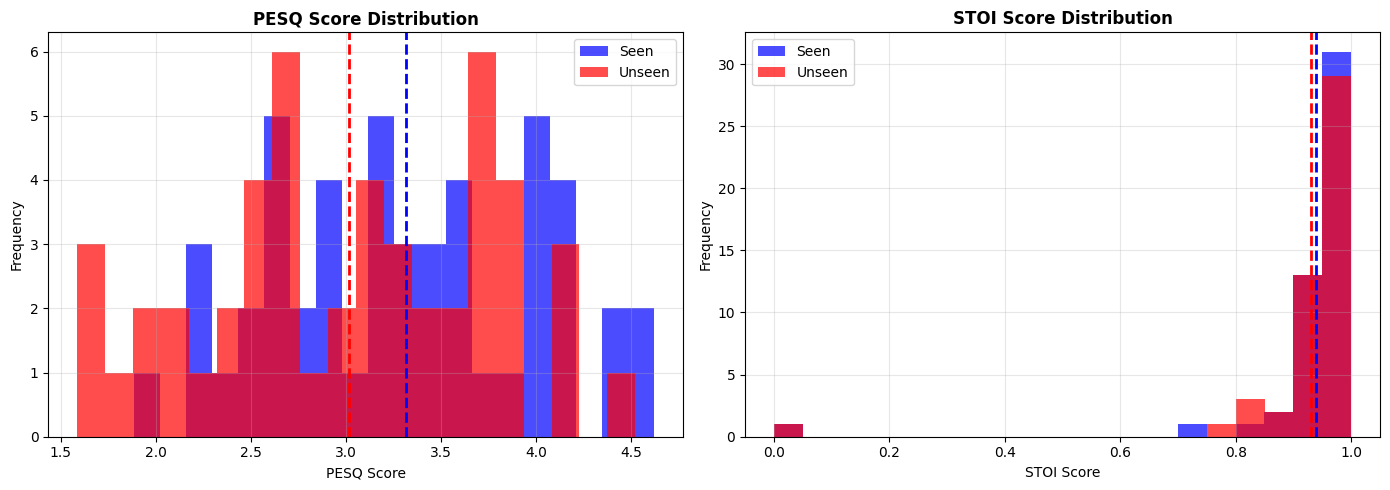

Metric distributions saved to /home/paul/Desktop/projects/clarity-net/results/baseline_cnn/metric_distributions.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PESQ distribution
axes[0].hist(results_seen['pesq_scores'], bins=20, alpha=0.7, label='Seen', color='blue')
axes[0].hist(results_unseen['pesq_scores'], bins=20, alpha=0.7, label='Unseen', color='red')
axes[0].axvline(results_seen['pesq_mean'], color='blue', linestyle='--', linewidth=2)
axes[0].axvline(results_unseen['pesq_mean'], color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('PESQ Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('PESQ Score Distribution', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# STOI distribution
axes[1].hist(results_seen['stoi_scores'], bins=20, alpha=0.7, label='Seen', color='blue')
axes[1].hist(results_unseen['stoi_scores'], bins=20, alpha=0.7, label='Unseen', color='red')
axes[1].axvline(results_seen['stoi_mean'], color='blue', linestyle='--', linewidth=2)
axes[1].axvline(results_unseen['stoi_mean'], color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('STOI Score')
axes[1].set_ylabel('Frequency')
axes[1].set_title('STOI Score Distribution', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'metric_distributions.png', dpi=150)
plt.show()

print(f"Metric distributions saved to {RESULTS_DIR / 'metric_distributions.png'}")

## Summary

### What We've Accomplished:

1. ✅ **Loaded data** from notebook 02 setup
2. ✅ **Created U-Net CNN baseline** with ~1.8M parameters
3. ✅ **Trained with proper validation** on seen and unseen noise
4. ✅ **Tracked generalization gap** throughout training
5. ✅ **Saved checkpoints** and training history

### Key Observations:

- **Training loss** should decrease steadily
- **Val (seen) loss** should track training loss (with gap = overfitting)
- **Val (unseen) loss** will be higher (this is the generalization gap)
- **Generalization gap** = your core research metric

### Next Steps:

1. Implement PESQ/STOI metrics for better evaluation
2. Train SOTA models (DeepFilterNet, DCCRN)
3. Implement ablations (augmentation, curriculum learning)
4. Compare all models on final test sets

### Files Created:

- `checkpoints/baseline_cnn/best_model.pth` — Best model checkpoint
- `checkpoints/baseline_cnn/training_history.json` — Loss curves data
- `checkpoints/baseline_cnn/training_curves.png` — Visualization